In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt, welch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

DATA_DIR = Path("../../data")
EPN_DIR = DATA_DIR / "epn612" / "raw"

FS = 200  # Hz, Myo armband sampling rate
GESTURES = ["noGesture", "open", "pinch", "waveOut", "fist", "waveIn"]
N_CHANNELS = 8

DRIFT_CUTOFF_HZ = 20.0
_highpass_sos = butter(4, DRIFT_CUTOFF_HZ, btype="highpass", fs=FS, output="sos")


def apply_highpass(x: np.ndarray) -> np.ndarray:
    """Zero-phase Butterworth high-pass (removes DC offset and sub-20Hz drift) --
    same SENIAM-convention filter used throughout this project's notebooks."""
    return sosfiltfilt(_highpass_sos, x, axis=-1)


def find_epn_user_files(root: Path, splits=("trainingJSON",), n=None):
    files = []
    for split in splits:
        files += sorted(
            root.rglob(f"{split}/user*/user*.json"),
            key=lambda p: int("".join(filter(str.isdigit, p.stem))),
        )
    return files if n is None else files[:n]


def samples_for_gesture(user_json: dict, gesture: str, n=None):
    out = []
    for split in ("trainingSamples", "testingSamples"):
        for sample in user_json.get(split, {}).values():
            if sample.get("gestureName") == gesture:
                out.append(sample["emg"])
                if n is not None and len(out) == n:
                    return out
    return out


def per_channel_features(x: np.ndarray) -> dict:
    """MAV + Fourier-domain features (Welch PSD), same trio used in
    epn612_crosstalk_causal_diagrams.ipynb -- kept identical so results here
    are directly comparable to that notebook's GFCI/ICP findings."""
    feats = {}
    feats["mav"] = np.mean(np.abs(x))
    nperseg = min(len(x), int(FS * 2.0))
    freqs, psd = welch(x, fs=FS, nperseg=nperseg)
    peak_idx = np.argmax(psd)
    feats["fft_peak_freq"] = freqs[peak_idx]
    feats["fft_mean_freq"] = np.sum(freqs * psd) / psd.sum()
    return feats


def load_wide_windows(splits=("trainingJSON",), n_users=None, trials_per_gesture=None):
    rows = []
    files = find_epn_user_files(EPN_DIR, splits=splits, n=n_users)
    for k, path in enumerate(files, 1):
        user_json = json.loads(path.read_text())
        age = user_json["userInfo"]["age"]
        dist_elbow_ulna = user_json["userInfo"]["distanceFromElbowToUlnaInCm"]
        uid = path.parent.name
        for gesture in GESTURES:
            for emg_dict in samples_for_gesture(user_json, gesture, trials_per_gesture):
                row = {
                    "user": uid,
                    "gesture": gesture,
                    "age": age,
                    "distanceFromElbowToUlnaInCm": dist_elbow_ulna,
                }
                for ch in range(1, N_CHANNELS + 1):
                    x = apply_highpass(np.array(emg_dict[f"ch{ch}"], dtype=float))
                    for name, value in per_channel_features(x).items():
                        row[f"ch{ch}_{name}"] = value
                rows.append(row)
        if k % 50 == 0 or k == len(files):
            print(f"  loaded {k}/{len(files)} users, {len(rows)} windows so far")
    return pd.DataFrame(rows)


wide_df = load_wide_windows(("trainingJSON",), n_users=None, trials_per_gesture=3)
FEATURE_COLS_WIDE = [c for c in wide_df.columns if c.startswith("ch") and ("mav" in c or "fft" in c)]
print(f"\n{wide_df.shape[0]} rows, {len(FEATURE_COLS_WIDE)} features, age range {wide_df['age'].min()}-{wide_df['age'].max()}")
wide_df.head()

  loaded 50/306 users, 900 windows so far
  loaded 100/306 users, 1800 windows so far
  loaded 150/306 users, 2700 windows so far
  loaded 200/306 users, 3600 windows so far
  loaded 250/306 users, 4500 windows so far
  loaded 300/306 users, 5400 windows so far
  loaded 306/306 users, 5508 windows so far

5508 rows, 24 features, age range 18-54


,user,gesture,age,distanceFromElbowToUlnaInCm,ch1_mav,ch1_fft_peak_freq,ch1_fft_mean_freq,ch2_mav,ch2_fft_peak_freq,ch2_fft_mean_freq,...,ch5_fft_mean_freq,ch6_mav,ch6_fft_peak_freq,ch6_fft_mean_freq,ch7_mav,ch7_fft_peak_freq,ch7_fft_mean_freq,ch8_mav,ch8_fft_peak_freq,ch8_fft_mean_freq
0,user1,noGesture,19,24.0,0.895392,72.5,63.454799,2.141860,69.5,65.528485,...,62.722870,0.957900,88.0,62.268805,0.743140,91.5,60.436754,0.764259,88.5,60.697561
1,user1,noGesture,19,24.0,0.936866,87.0,60.532207,1.766218,68.0,61.803224,...,64.008650,0.968333,73.0,60.045452,0.791993,88.0,61.995388,0.768542,82.0,61.913615
2,user1,noGesture,19,24.0,1.100648,45.0,62.922172,2.966961,91.0,64.009454,...,60.165651,0.998615,29.5,62.335222,0.795677,76.5,59.992599,0.844713,90.0,62.737565
3,user1,open,19,24.0,2.536149,84.5,67.546129,8.608215,76.5,67.681557,...,62.790041,1.933941,65.5,61.215896,1.967835,66.5,60.764028,3.952365,68.5,67.371262
4,user1,open,19,24.0,2.110451,70.5,69.443459,6.037057,88.0,66.892632,...,64.941584,1.947802,87.0,69.948563,1.773373,83.0,69.633400,2.652607,67.0,60.070690


In [2]:
import anchorboosting as ab
from sklearn.metrics import roc_auc_score, accuracy_score

FEATURE_COLS_ICP = [
   'ch1_fft_mean_freq', 'ch1_fft_peak_freq', 'ch1_mav', 'ch2_mav', 'ch3_fft_mean_freq', 'ch3_mav', 'ch4_fft_mean_freq', 'ch4_mav', 'ch5_fft_mean_freq', 'ch5_fft_peak_freq', 'ch5_mav', 'ch6_fft_mean_freq', 'ch6_mav', 'ch7_fft_mean_freq', 'ch7_mav', 'ch8_fft_mean_freq', 'ch8_mav'
]  


def ulna_distance_group(dist: int) -> str:
    if dist < 22:
        return "10-22"
    elif dist < 27:
        return "22-27"
    else:
        return "27+"


wide_df["dist_group"] = wide_df["distanceFromElbowToUlnaInCm"].apply(ulna_distance_group)
train_mask = wide_df["dist_group"] != "27+"
test_mask = wide_df["dist_group"] == "27+"
print(f"train rows (10-22 + 22-27): {train_mask.sum()}, held-out test rows (27+): {test_mask.sum()}")

X_train_boost = wide_df.loc[train_mask, FEATURE_COLS_ICP]
X_test_boost = wide_df.loc[test_mask, FEATURE_COLS_ICP]
dist_train_boost = pd.get_dummies(wide_df.loc[train_mask, "dist_group"]).values.astype(float)

ACTIVE_GESTURES = [g for g in GESTURES if g != "noGesture"]  

boost_results = []
contrib_rows = []  
for gesture in ACTIVE_GESTURES:
    y_train = (wide_df.loc[train_mask, "gesture"] == gesture).astype(float).values
    y_test = (wide_df.loc[test_mask, "gesture"] == gesture).astype(float).values
    row = {"gesture": gesture}
    # Plain no importance to anchor variable
    # Robust importance to anchor variable
    for gamma, label in [(1, "plain"), (30, "robust")]:
        m = ab.AnchorBooster(gamma=gamma, objective="binary",
                              verbosity=0, seed=1)
        m.fit(X_train_boost, y_train, Z=dist_train_boost)
        p_test = m.predict(X_test_boost)
        row[f"{label}_auc"] = roc_auc_score(y_test, p_test)
        row[f"{label}_acc"] = accuracy_score(y_test, p_test > 0.5)

        mean_contrib = m.booster_.feature_importance(importance_type="gain")
        for feat, c in zip(FEATURE_COLS_ICP, mean_contrib):
            contrib_rows.append({"gesture": gesture, "model": label, "feature": feat, "mean_contrib": c})
    boost_results.append(row)
    print(row, flush=True)


train rows (10-22 + 22-27): 4050, held-out test rows (27+): 1458
{'gesture': 'open', 'plain_auc': 0.8455249030466222, 'plain_acc': 0.8580246913580247, 'robust_auc': 0.8457044149773917, 'robust_acc': 0.8662551440329218}
{'gesture': 'pinch', 'plain_auc': 0.8588900743450355, 'plain_acc': 0.879286694101509, 'robust_auc': 0.8577452624091857, 'robust_acc': 0.8813443072702332}
{'gesture': 'waveOut', 'plain_auc': 0.9269521922471169, 'plain_acc': 0.892318244170096, 'robust_auc': 0.9319412691154805, 'robust_acc': 0.8991769547325102}
{'gesture': 'fist', 'plain_auc': 0.9089434198716321, 'plain_acc': 0.8861454046639232, 'robust_auc': 0.9132991244559603, 'robust_acc': 0.8888888888888888}
{'gesture': 'waveIn', 'plain_auc': 0.9177835357076326, 'plain_acc': 0.8930041152263375, 'robust_auc': 0.9214855459025555, 'robust_acc': 0.8909465020576132}


In [3]:
boost_results_df = pd.DataFrame(boost_results).set_index("gesture")
boost_results_df["auc_pct_change"] = (
    ((boost_results_df["robust_auc"] - boost_results_df["plain_auc"]) / boost_results_df["plain_auc"]) * 100
)
boost_results_df["acc_pct_change"] = (
    ((boost_results_df["robust_acc"] - boost_results_df["plain_acc"]) / boost_results_df["plain_acc"]) * 100
)
boost_results_df

,plain_auc,plain_acc,robust_auc,robust_acc,auc_pct_change,acc_pct_change
gesture,,,,,,
open,0.845525,0.858025,0.845704,0.866255,0.021231,0.959233
pinch,0.858890,0.879287,0.857745,0.881344,-0.133290,0.234009
waveOut,0.926952,0.892318,0.931941,0.899177,0.538224,0.768640
fist,0.908943,0.886145,0.913299,0.888889,0.479205,0.309598
waveIn,0.917784,0.893004,0.921486,0.890947,0.403364,-0.230415


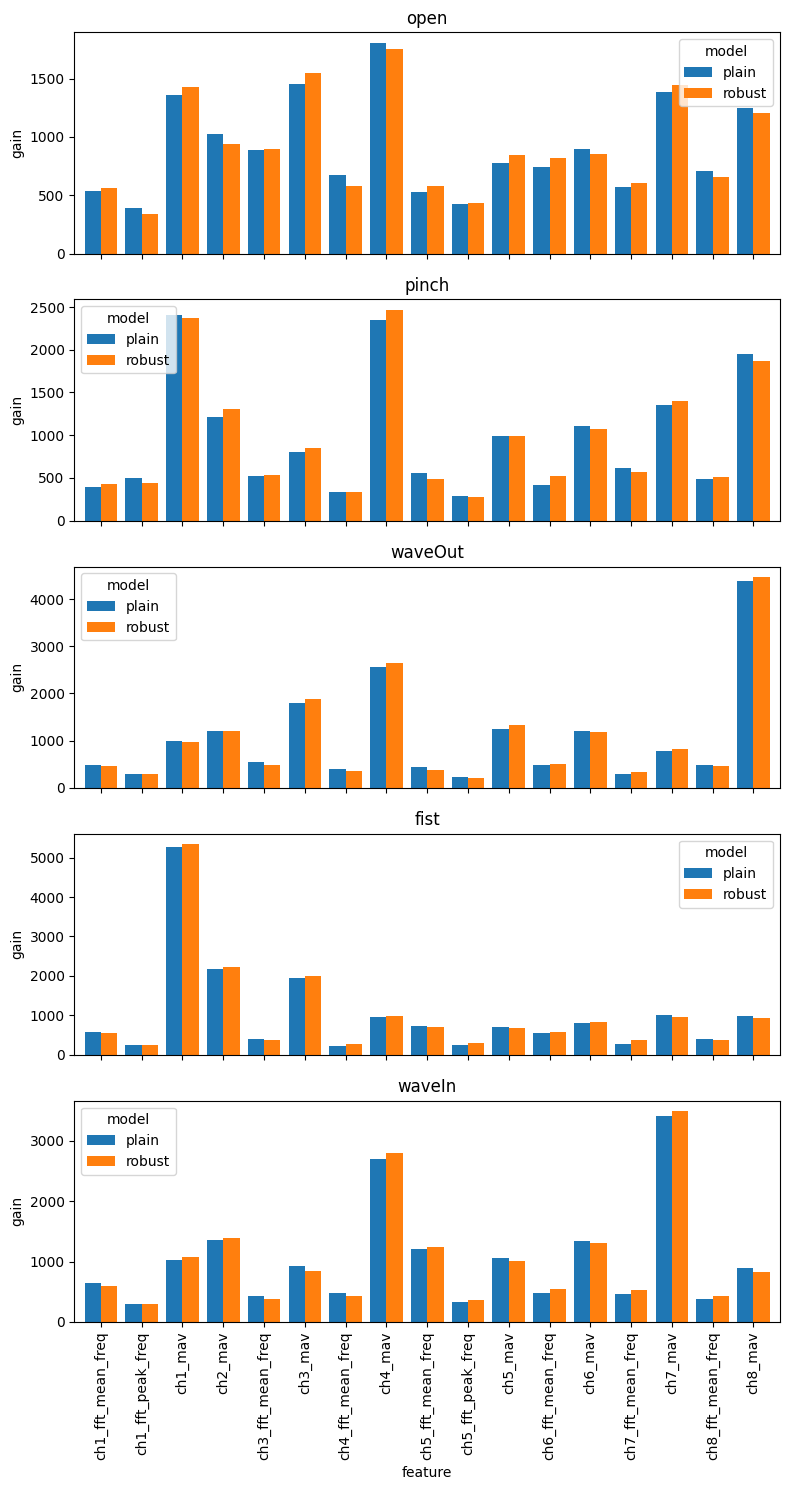

In [4]:
contrib_df = pd.DataFrame(contrib_rows)

fig, axes = plt.subplots(len(ACTIVE_GESTURES), 1, figsize=(8, 3 * len(ACTIVE_GESTURES)), sharex=True)
for ax, gesture in zip(axes, ACTIVE_GESTURES):
    sub = (
        contrib_df[contrib_df["gesture"] == gesture]
        .pivot(index="feature", columns="model", values="mean_contrib")
        .reindex(FEATURE_COLS_ICP)
    )
    sub.plot(kind="bar", ax=ax, width=0.8)
    ax.set_title(gesture)
    ax.set_ylabel("gain")
    ax.legend(title="model")
axes[-1].set_xlabel("feature")
plt.tight_layout()
plt.show()